In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample-Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


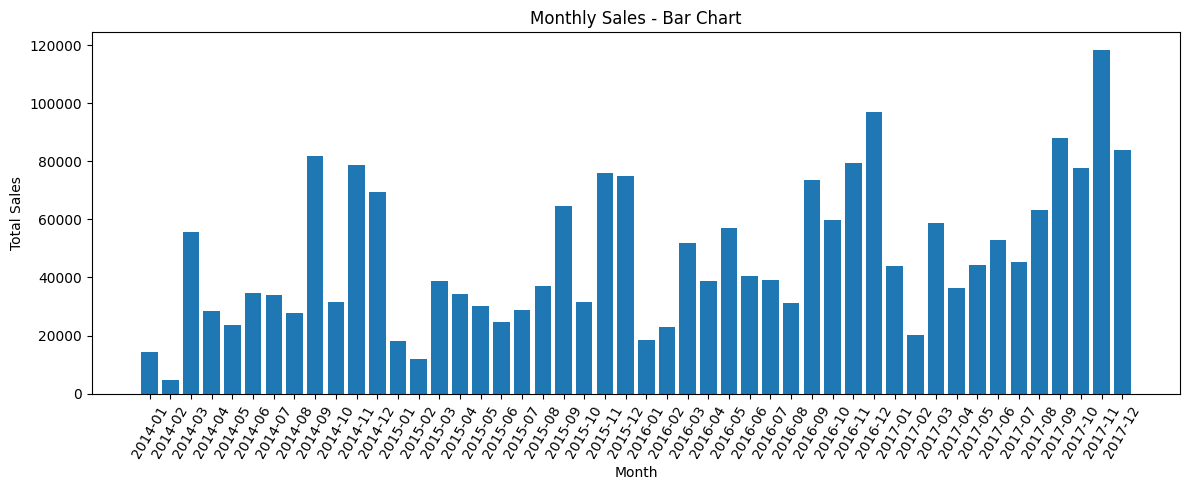

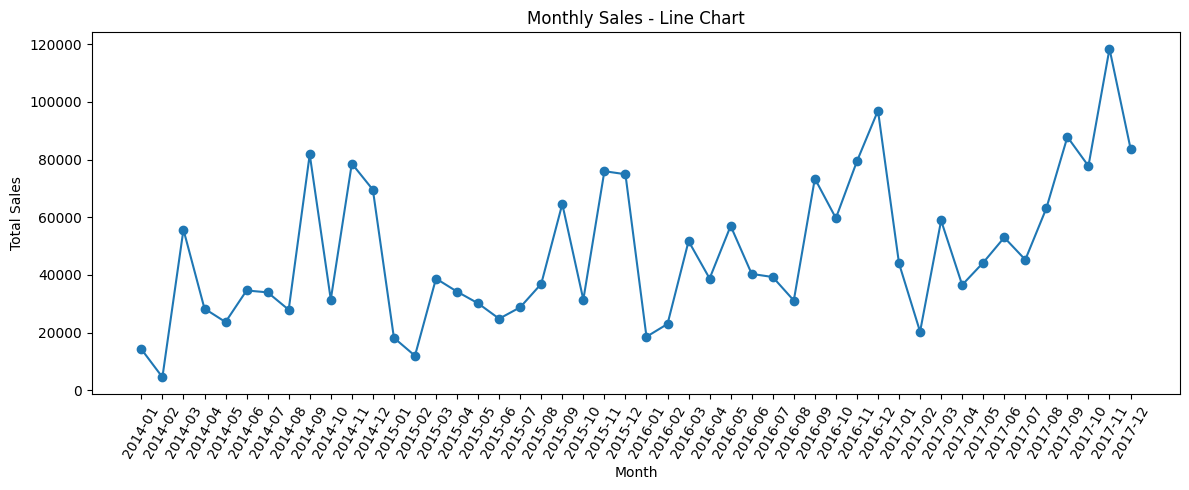

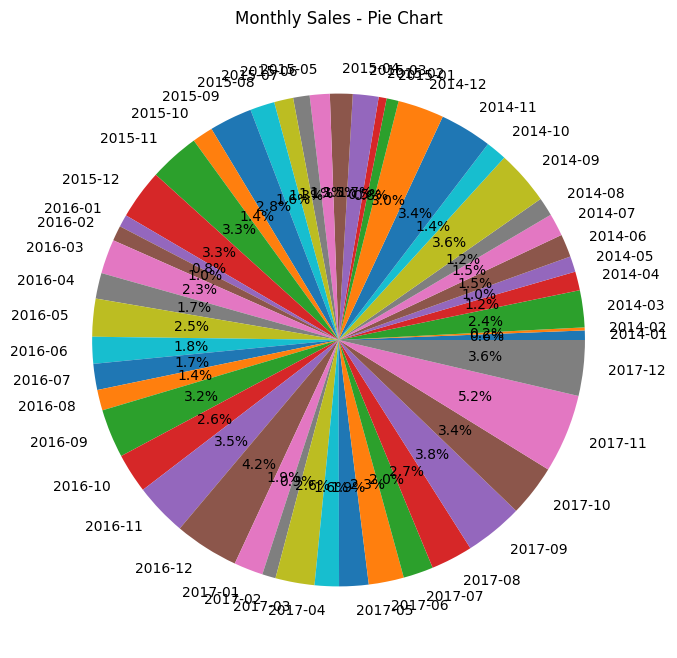

In [3]:
#task 01
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales - Bar Chart")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales - Line Chart")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(
    monthly_sales.values,
    labels=monthly_sales.index,
    autopct="%1.1f%%"
)
plt.title("Monthly Sales - Pie Chart")
plt.show()

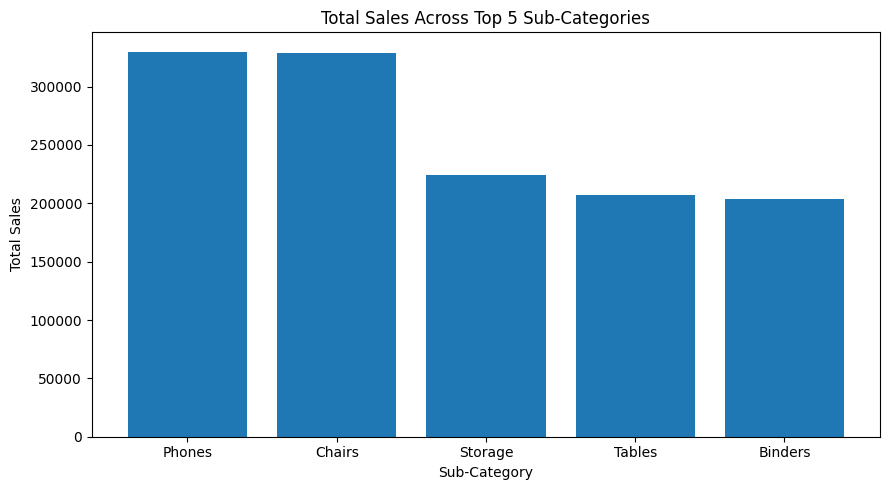

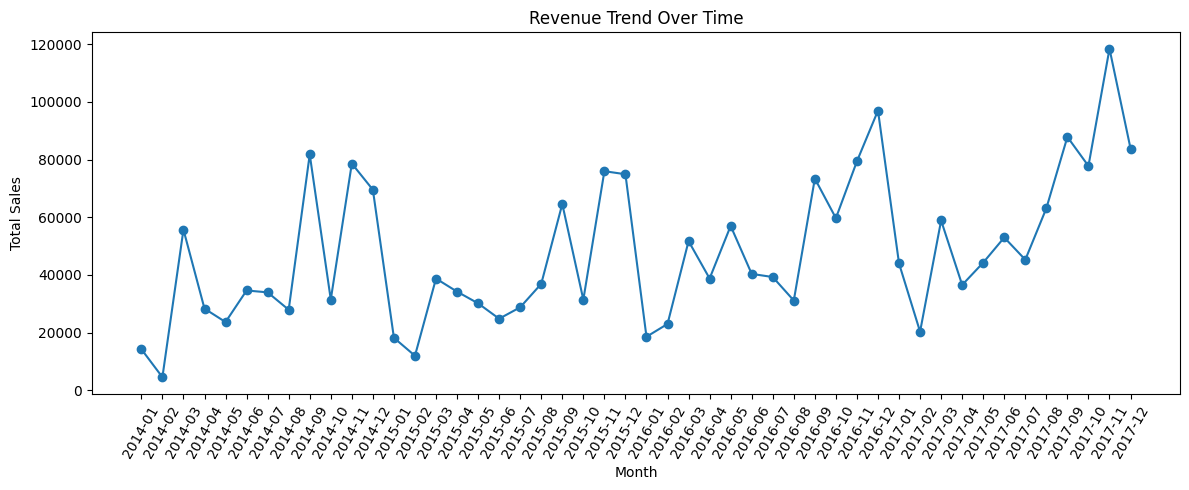

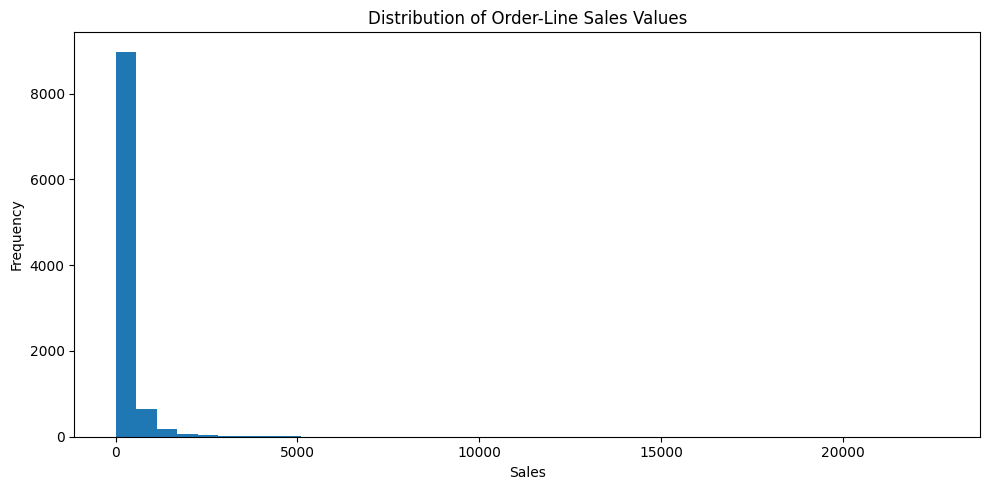

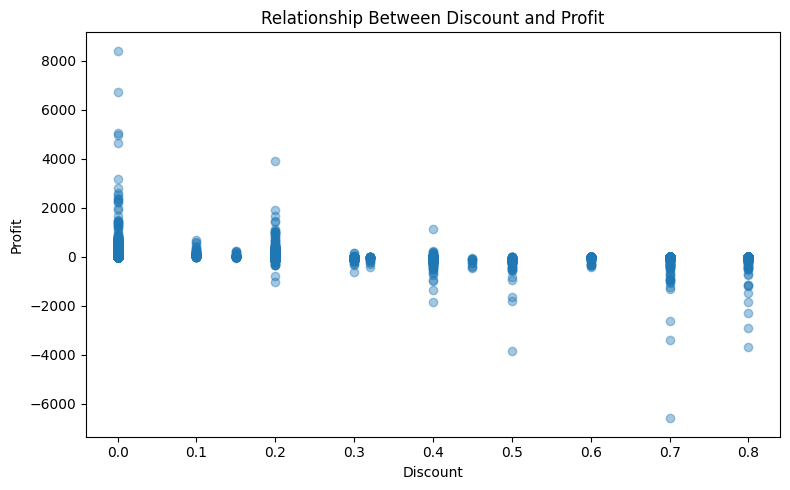

In [4]:
#task 02
top5 = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(9, 5))
plt.bar(top5.index, top5.values)
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.title("Total Sales Across Top 5 Sub-Categories")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Revenue Trend Over Time")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.hist(df["Sales"], bins=40)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Order-Line Sales Values")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Relationship Between Discount and Profit")
plt.tight_layout()
plt.show()

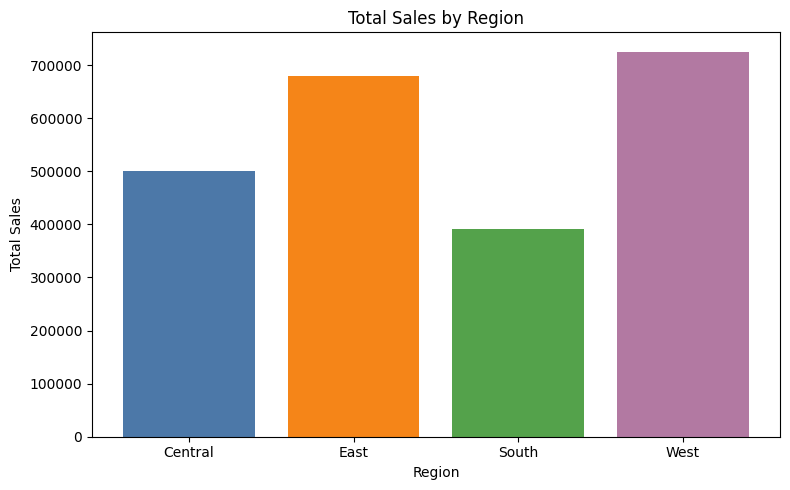

In [5]:
#task 03 -a
region_sales = df.groupby("Region")["Sales"].sum()

colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values, color=colors)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")
plt.tight_layout()
plt.show()

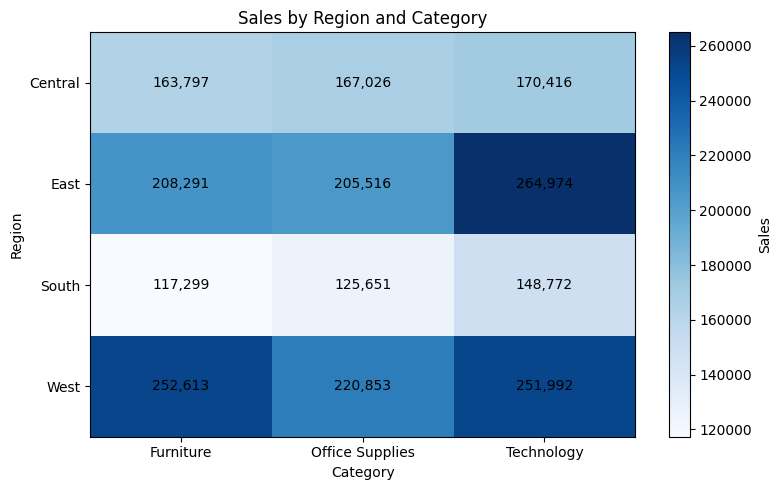

In [6]:
#task 03- b
region_category = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum"
)

plt.figure(figsize=(8,5))
plt.imshow(region_category, cmap="Blues", aspect="auto")

plt.xticks(range(len(region_category.columns)), region_category.columns)
plt.yticks(range(len(region_category.index)), region_category.index)

plt.xlabel("Category")
plt.ylabel("Region")
plt.title("Sales by Region and Category")

plt.colorbar(label="Sales")

for i in range(len(region_category.index)):
    for j in range(len(region_category.columns)):
        plt.text(
            j, i,
            f"{region_category.iloc[i, j]:,.0f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

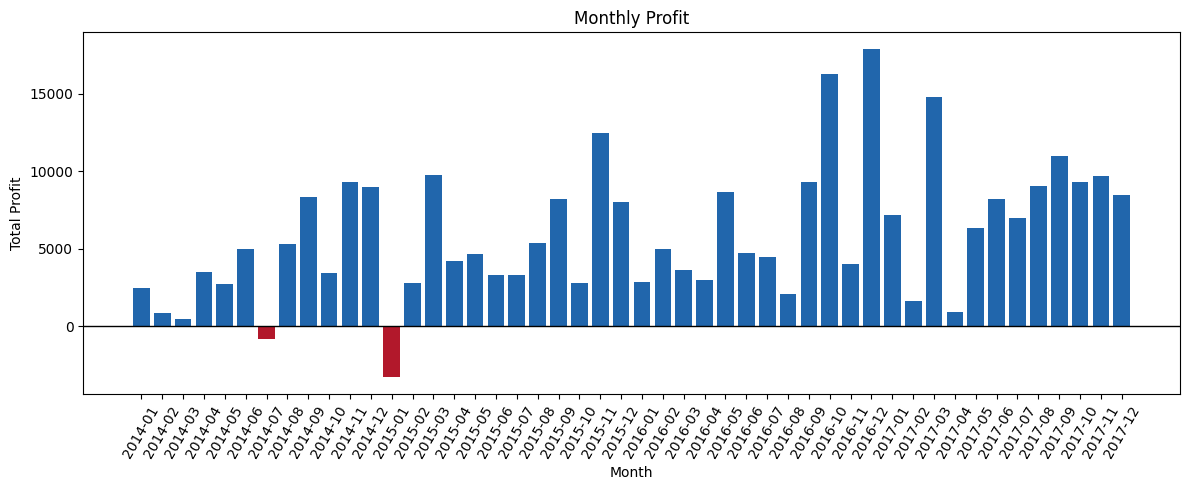

In [7]:
#task 03 -c
monthly_profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()

monthly_profit.index = monthly_profit.index.astype(str)

colors = ["#B2182B" if x < 0 else "#2166AC" for x in monthly_profit.values]

plt.figure(figsize=(12,5))
plt.bar(monthly_profit.index, monthly_profit.values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.title("Monthly Profit")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [8]:
#task 04- a
def relative_luminance(rgb):
    rgb = [x / 255 for x in rgb]
    
    rgb = [x / 12.92 if x <= 0.03928 else ((x + 0.055) / 1.055) ** 2.4for x in rgb]
    
    return (0.2126 * rgb[0] +0.7152 * rgb[1] +0.0722 * rgb[2]
    )

def contrast_ratio(color1, color2):
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)
    
    lighter = max(l1, l2)
    darker = min(l1, l2)
    
    return (lighter + 0.05) / (darker + 0.05)

colors = {
    "Blue": (76, 120, 168),
    "Orange": (245, 133, 24),
    "Green": (84, 162, 75),
    "Purple": (178, 121, 162),
    "Red": (178, 24, 43),
    "Dark Blue": (33, 102, 172)
}

for name, color in colors.items():
    ratio = contrast_ratio(color, (255, 255, 255))
    
    if ratio >= 4.5:
        print(name, ":", round(ratio, 2), "PASS")
    else:
        print(name, ":", round(ratio, 2), "FAIL")

Blue : 4.61 PASS
Orange : 2.55 FAIL
Green : 3.16 FAIL
Purple : 3.41 FAIL
Red : 6.87 PASS
Dark Blue : 5.9 PASS


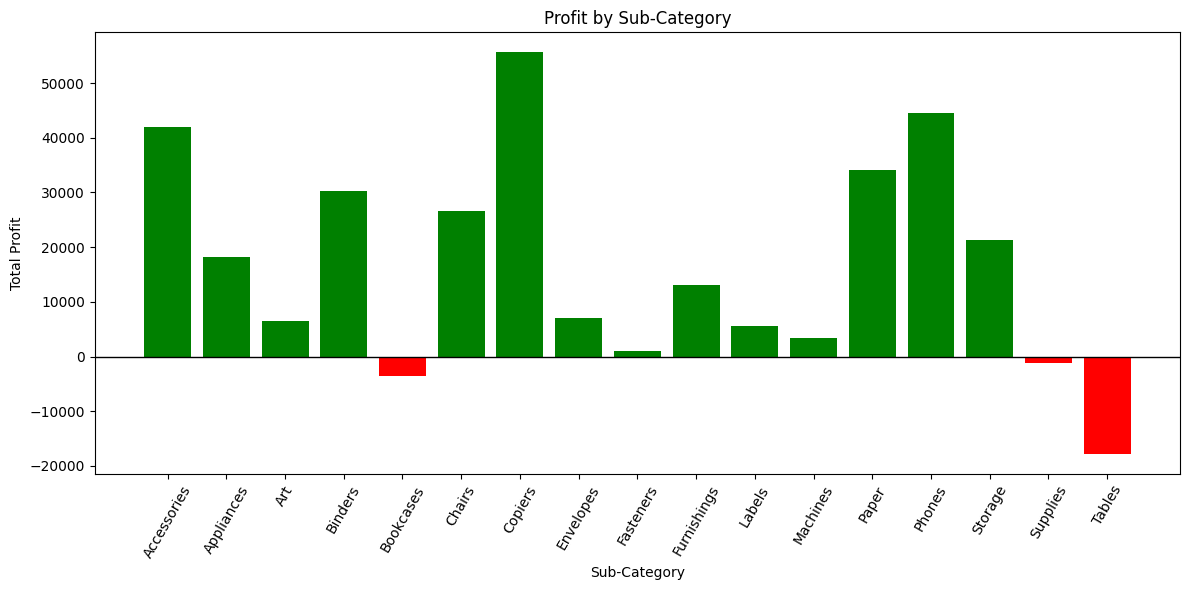

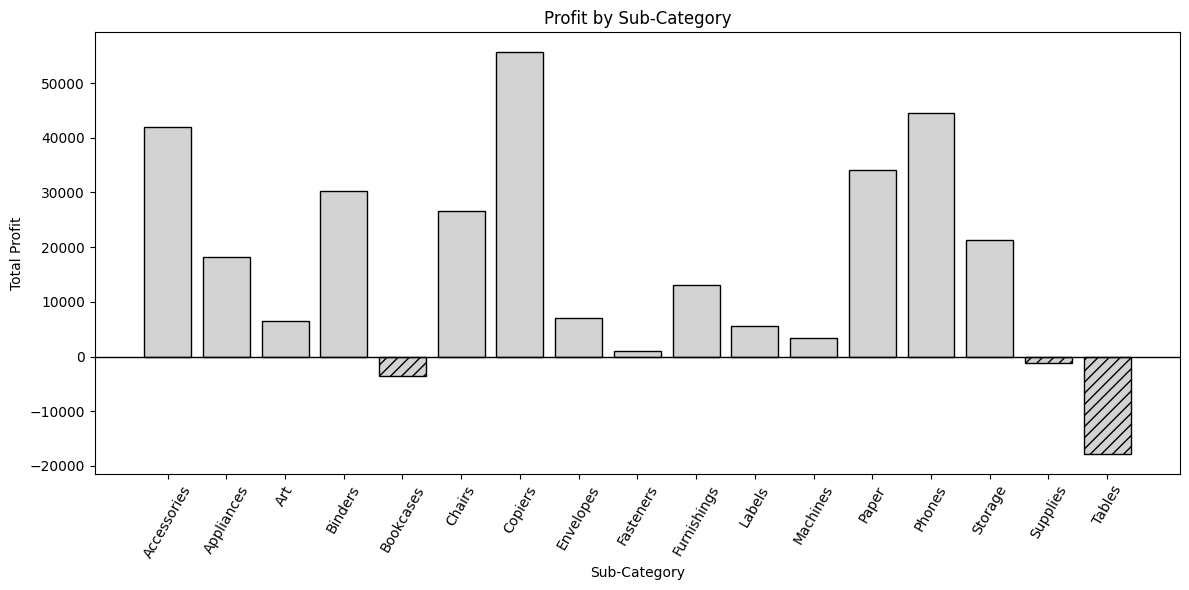

In [9]:
#task 04- b
sub_category_profit = df.groupby("Sub-Category")["Profit"].sum()

colors = ["green" if x >= 0 else "red" for x in sub_category_profit.values]

plt.figure(figsize=(12, 6))
plt.bar(sub_category_profit.index, sub_category_profit.values, color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.title("Profit by Sub-Category")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for i, value in enumerate(sub_category_profit.values):
    if value < 0:
        plt.bar(i, value, color="lightgray", edgecolor="black", hatch="///")
    else:
        plt.bar(i, value, color="lightgray", edgecolor="black")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.title("Profit by Sub-Category")
plt.xticks(range(len(sub_category_profit)), sub_category_profit.index, rotation=60)
plt.tight_layout()
plt.show()

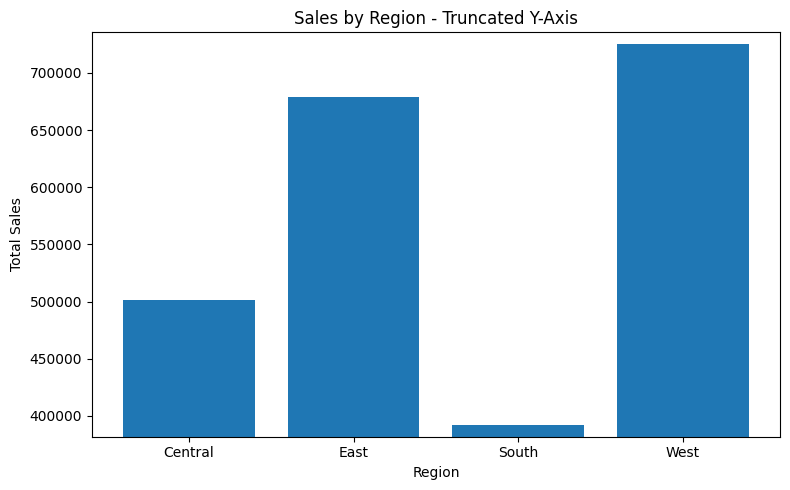

In [10]:
#task 05 -a
plt.figure(figsize=(8,5))

plt.bar(region_sales.index, region_sales.values)

plt.ylim(region_sales.min() - 10000, region_sales.max() + 10000)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Sales by Region - Truncated Y-Axis")

plt.tight_layout()
plt.show()

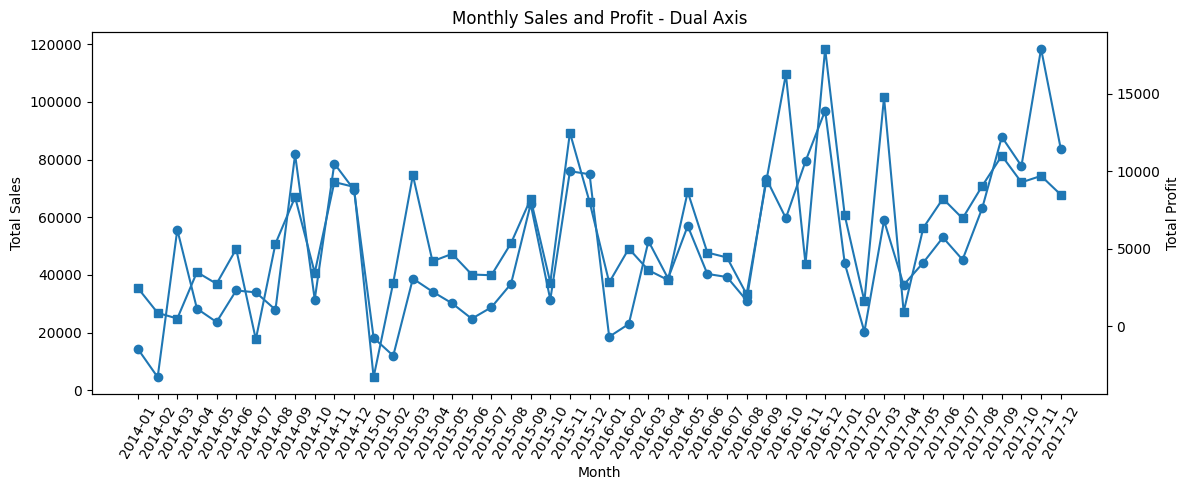

In [11]:
# task 05 -b
fig, ax1 = plt.subplots(figsize=(12,5))

ax2 = ax1.twinx()

ax1.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

ax2.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="s"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Sales")
ax2.set_ylabel("Total Profit")

ax1.set_title("Monthly Sales and Profit - Dual Axis")

ax1.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

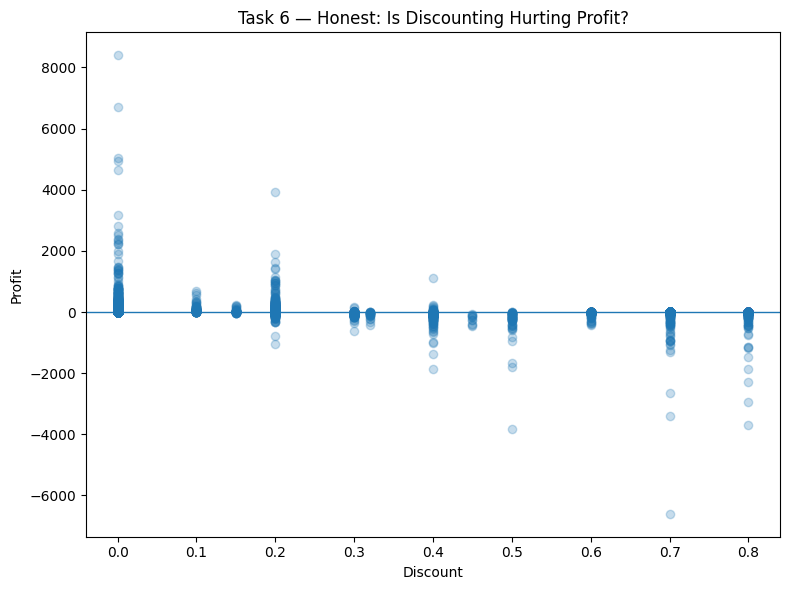

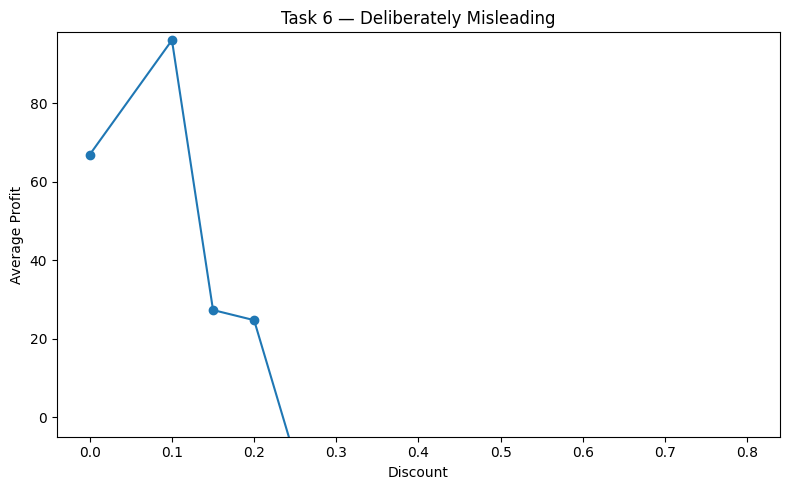

In [12]:
#task 06
plt.figure(figsize=(8,6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.25)
plt.axhline(0, linewidth=1)
plt.xlabel("Discount"); plt.ylabel("Profit")
plt.title("Task 6 — Honest: Is Discounting Hurting Profit?")
plt.tight_layout(); plt.show()


mean_profit_discount = df.groupby("Discount", as_index=False)["Profit"].mean()
plt.figure(figsize=(8,5))
plt.plot(mean_profit_discount["Discount"], mean_profit_discount["Profit"], marker="o")
mn, mx = mean_profit_discount["Profit"].min(), mean_profit_discount["Profit"].max()
plt.ylim(max(mn-2, -5), mx+2)
plt.xlabel("Discount"); plt.ylabel("Average Profit")
plt.title("Task 6 — Deliberately Misleading")
plt.tight_layout(); plt.show()